# 🎨 Laboratorio · Espacios de Color

**Curso:** CC53 — Procesamiento de Imágenes  
**Sesión:** 2 horas  
**Basado en:** González & Woods, *Digital Image Processing*, 3rd ed. — Capítulo 6

---

## Objetivos de la sesión

Al final de este lab podrás:

1. Separar y visualizar los canales de una imagen en **RGB**.
2. Convertir entre **RGB ↔ CMY/CMYK** (fórmula 6.2-1 del libro).
3. **Implementar a mano** las conversiones **RGB ↔ HSI** (ecuaciones 6.2-2 a 6.2-4).
4. **Manipular una imagen en el espacio HSI** para lograr efectos que serían imposibles en RGB:
   - cambiar el matiz global sin tocar iluminación
   - aumentar/reducir saturación
   - trabajar solo con intensidad (modo "B&W con color")
5. Comparar tu implementación con la de **OpenCV** para validar.

## Plan cronometrado

| Bloque | Tiempo | Contenido |
|--------|--------|-----------|
| 0 · Setup | 10 min | Imports, carga de imagen, estilo visual |
| 1 · RGB | 15 min | Separación de canales, cubo RGB |
| 2 · CMYK | 15 min | Fórmula 6.2-1 y visualización |
| 3 · RGB → HSI | 25 min | Implementación manual + verificación |
| 4 · HSI → RGB | 20 min | Conversión inversa por sectores |
| 5 · Manipulación HSI | 25 min | Efectos creativos usando HSI |
| 6 · Juego libre | 10 min | Tu propia imagen, tus propios efectos |

> 💡 **Tip:** Ejecuta todas las celdas en orden la primera vez. Después puedes saltar a donde quieras.


---
## 📦 Bloque 0 · Setup

Importamos librerías y configuramos el estilo oscuro para que los gráficos combinen con la presentación.


In [1]:
# --- Librerías base ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import urllib.request
from io import BytesIO

# --- Estilo oscuro (matching con la presentación) ---
plt.rcParams.update({
    'figure.facecolor':   '#0A0E27',
    'axes.facecolor':     '#151A3D',
    'axes.edgecolor':     '#2A3159',
    'axes.labelcolor':    '#F5F7FF',
    'xtick.color':        '#9AA3C7',
    'ytick.color':        '#9AA3C7',
    'text.color':         '#F5F7FF',
    'axes.titlecolor':    '#00E5FF',
    'axes.titleweight':   'bold',
    'font.family':        'DejaVu Sans',
    'font.size':          10,
    'figure.dpi':         90,
})

# Paleta "Prism" de la sesión
CYAN    = '#00E5FF'
MAGENTA = '#FF2D95'
YELLOW  = '#FFD60A'
TEXT    = '#F5F7FF'

print('✓ Librerías cargadas')
print(f'  NumPy      {np.__version__}')
print(f'  Matplotlib {plt.matplotlib.__version__}')
print(f'  Pillow     {Image.__version__ if hasattr(Image, "__version__") else "ok"}')


✓ Librerías cargadas
  NumPy      2.0.2
  Matplotlib 3.10.0
  Pillow     11.3.0


### Cargamos una imagen de prueba

Vamos a usar una imagen de muestra con buena variedad de colores. Si tienes internet, descargamos un pimiento (ejemplo clásico de la comunidad de procesamiento de imágenes). Si no, generamos una imagen sintética.


⚠ No se pudo descargar (motivo: HTTPError). Generando imagen sintética.
Forma: (300, 400, 3)  (alto, ancho, canales)
Tipo:  uint8
Rango: [30, 255]


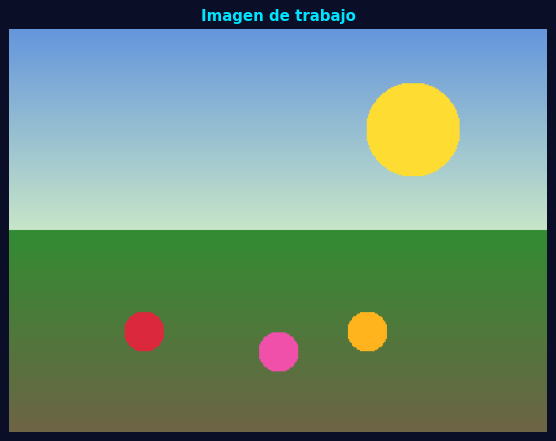

In [2]:
def cargar_imagen_muestra():
    """Intenta descargar una imagen de internet; si falla, genera una sintética."""
    try:
        url = 'https://upload.wikimedia.org/wikipedia/commons/thumb/4/47/PNG_transparency_demonstration_1.png/280px-PNG_transparency_demonstration_1.png'
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req, timeout=5) as r:
            img = Image.open(BytesIO(r.read())).convert('RGB')
        print('✓ Imagen descargada de internet')
        return np.array(img)
    except Exception as e:
        print(f'⚠ No se pudo descargar (motivo: {type(e).__name__}). Generando imagen sintética.')
        return generar_imagen_sintetica()

def generar_imagen_sintetica(h=300, w=400):
    """Genera un paisaje sintético con cielo, sol, césped y flores."""
    img = np.zeros((h, w, 3), dtype=np.uint8)
    # Cielo (gradiente azul)
    for y in range(h // 2):
        t = y / (h // 2)
        img[y, :] = [int(100 + 100*t), int(150 + 80*t), int(220 - 20*t)]
    # Césped (gradiente verde)
    for y in range(h // 2, h):
        t = (y - h//2) / (h//2)
        img[y, :] = [int(50 + 60*t), int(140 - 40*t), int(50 + 20*t)]
    # Sol (círculo amarillo)
    cy, cx, r = h//4, 3*w//4, 35
    yy, xx = np.mgrid[:h, :w]
    sun = (yy - cy)**2 + (xx - cx)**2 < r**2
    img[sun] = [255, 220, 50]
    # Flores (círculos rojos y magenta)
    for (fx, fy, col) in [(w//4, 3*h//4, [220, 40, 60]),
                          (w//2, 4*h//5, [240, 80, 170]),
                          (2*w//3, 3*h//4, [255, 180, 30])]:
        flower = (yy - fy)**2 + (xx - fx)**2 < 15**2
        img[flower] = col
    return img

img = cargar_imagen_muestra()
print(f'Forma: {img.shape}  (alto, ancho, canales)')
print(f'Tipo:  {img.dtype}')
print(f'Rango: [{img.min()}, {img.max()}]')

plt.figure(figsize=(7, 5))
plt.imshow(img)
plt.title('Imagen de trabajo')
plt.axis('off')
plt.tight_layout()
plt.show()


---
## 🔴🟢🔵 Bloque 1 · RGB — separación de canales

Una imagen RGB es un array de forma `(H, W, 3)`. Cada capa es un canal:

- `img[:, :, 0]` → **Rojo** (R)
- `img[:, :, 1]` → **Verde** (G)
- `img[:, :, 2]` → **Azul** (B)

Cada canal por sí solo es una **imagen en escala de grises**: valores altos = ese canal está presente, valores bajos = ausente.

### ¿Qué esperar visualmente?

Si miramos una flor roja:
- Canal R será **brillante** en la flor (valores altos)
- Canales G y B serán **oscuros** ahí

Vamos a verificarlo.


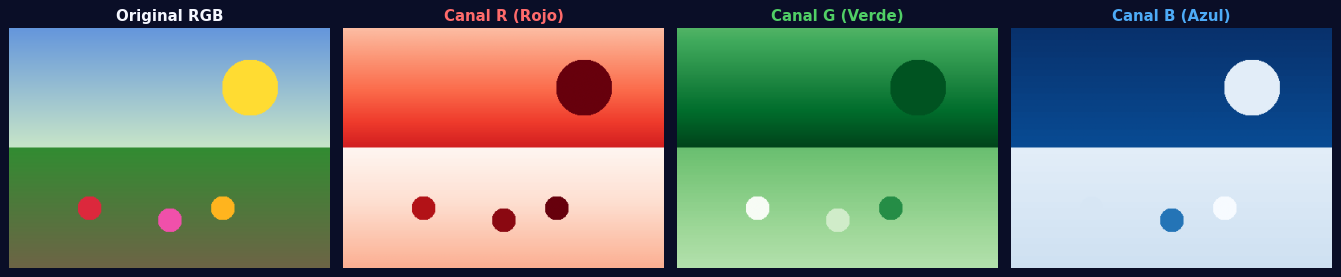

Promedio por canal: R=120.5, G=155.1, B=129.9


In [3]:
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

axes[0].imshow(img)
axes[0].set_title('Original RGB', color=TEXT)
axes[0].axis('off')

axes[1].imshow(R, cmap='Reds')
axes[1].set_title('Canal R (Rojo)', color='#FF6B6B')
axes[1].axis('off')

axes[2].imshow(G, cmap='Greens')
axes[2].set_title('Canal G (Verde)', color='#51CF66')
axes[2].axis('off')

axes[3].imshow(B, cmap='Blues')
axes[3].set_title('Canal B (Azul)', color='#4DABF7')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print(f'Promedio por canal: R={R.mean():.1f}, G={G.mean():.1f}, B={B.mean():.1f}')


### Mostrar cada canal "coloreado"

A veces es más intuitivo ver cada canal rellenando solo ese color (los demás en 0). Así se ve *literalmente* la contribución roja, verde y azul.


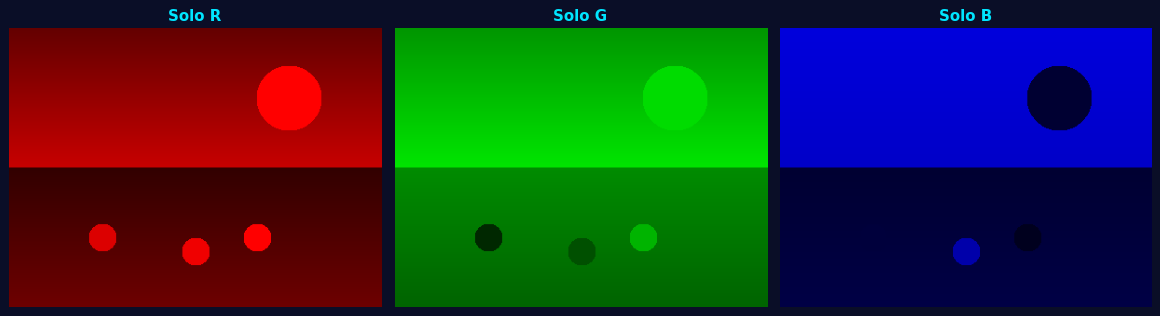

¿Suma de canales == original?  True


In [4]:
# Reconstruimos 3 imágenes, cada una con 2 canales puestos en 0
solo_R = np.zeros_like(img); solo_R[:,:,0] = R
solo_G = np.zeros_like(img); solo_G[:,:,1] = G
solo_B = np.zeros_like(img); solo_B[:,:,2] = B

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, im, title in zip(axes,
                          [solo_R, solo_G, solo_B],
                          ['Solo R', 'Solo G', 'Solo B']):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# Verificación: si sumamos los 3, recuperamos la imagen original
reconstruccion = solo_R + solo_G + solo_B
print(f'¿Suma de canales == original?  {np.array_equal(reconstruccion, img)}')


### 🎯 Ejercicio 1.1

Modifica el canal rojo de la imagen **multiplicándolo por 0.3** (reducir al 30%) y visualiza el resultado. ¿Qué pasa con el aspecto general? ¿A qué color tiende la imagen?

> *Pista: usa `img_mod = img.copy().astype(np.int32)` para no dañar la original, haz la operación, luego `np.clip(..., 0, 255).astype(np.uint8)`.*


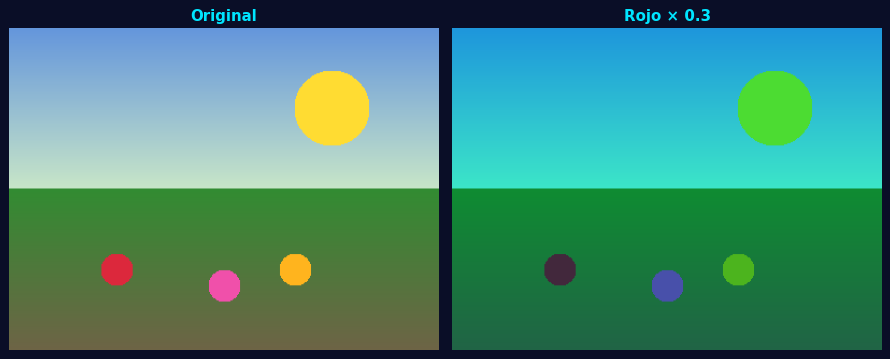

In [5]:
# TU CÓDIGO AQUÍ
img_mod = img.copy().astype(np.int32)
img_mod[:, :, 0] = (img_mod[:, :, 0] * 0.3).astype(np.int32)
img_mod = np.clip(img_mod, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img);     axes[0].set_title('Original');          axes[0].axis('off')
axes[1].imshow(img_mod); axes[1].set_title('Rojo × 0.3');        axes[1].axis('off')
plt.tight_layout(); plt.show()

# 💬 Reflexión: cuando reduces el rojo, lo que queda predomina → tendencia al cian
# (cian = verde + azul = lo opuesto al rojo en el cubo RGB).


---
## 🖨 Bloque 2 · CMYK — del RGB al mundo impreso

Del libro G&W, ecuación **(6.2-1)**:

$$\begin{bmatrix} C \\ M \\ Y \end{bmatrix} = \begin{bmatrix} 1 \\ 1 \\ 1 \end{bmatrix} - \begin{bmatrix} R \\ G \\ B \end{bmatrix}$$

con R, G, B **normalizados** al rango [0, 1].

La intuición: si un píxel es rojo puro (R=1, G=0, B=0), entonces su representación CMY es (0, 1, 1) — o sea *magenta* + *amarillo*, que al mezclarse como tintas dan rojo. Todo encaja. ✨

Para CMYK añadimos la extracción del negro (K) para ahorrar tinta y mejorar contraste:

$$K = \min(C, M, Y)$$
$$C' = C - K,\quad M' = M - K,\quad Y' = Y - K$$


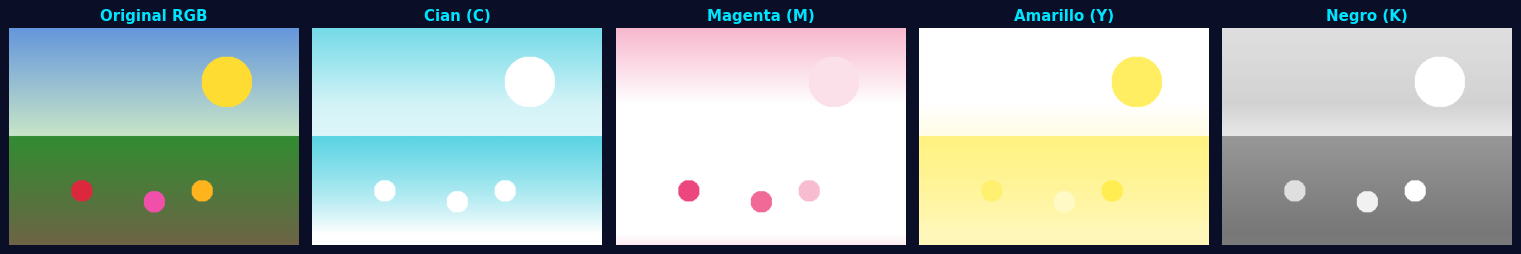

Cobertura promedio de tinta:
  C: 29.7%    M: 7.1%    Y: 28.6%    K: 33.1%


In [6]:
def rgb_to_cmy(rgb_uint8):
    """RGB [0..255] uint8  →  CMY [0..1] float."""
    rgb = rgb_uint8.astype(np.float32) / 255.0
    cmy = 1.0 - rgb
    return cmy

def rgb_to_cmyk(rgb_uint8):
    """RGB [0..255] uint8  →  (C', M', Y', K) todos en [0..1]."""
    cmy = rgb_to_cmy(rgb_uint8)
    K = cmy.min(axis=2)                 # negro = la menor cantidad común de CMY
    # Evitar división por cero: donde K=1 (negro puro), C'=M'=Y'=0
    denom = 1.0 - K
    safe = denom > 1e-6
    Cp = np.zeros_like(K); Mp = np.zeros_like(K); Yp = np.zeros_like(K)
    Cp[safe] = (cmy[:, :, 0][safe] - K[safe]) / denom[safe]
    Mp[safe] = (cmy[:, :, 1][safe] - K[safe]) / denom[safe]
    Yp[safe] = (cmy[:, :, 2][safe] - K[safe]) / denom[safe]
    return Cp, Mp, Yp, K

# --- Aplicamos a nuestra imagen ---
cmy = rgb_to_cmy(img)
C, M, Y, K = rgb_to_cmyk(img)

# --- Visualizamos las 4 componentes CMYK ---
# Para mostrar cada canal con su color correspondiente, usamos cmaps personalizados
def make_cmap(name, color_hex):
    """Colormap que va de blanco (valor bajo = poca tinta) a color puro (valor alto)."""
    return LinearSegmentedColormap.from_list(name, ['#FFFFFF', color_hex])

cmap_C = make_cmap('cian',     '#00BCD4')
cmap_M = make_cmap('magenta',  '#E91E63')
cmap_Y = make_cmap('amarillo', '#FFEB3B')
cmap_K = make_cmap('negro',    '#1A1A1A')

fig, axes = plt.subplots(1, 5, figsize=(17, 3.5))
axes[0].imshow(img);             axes[0].set_title('Original RGB');      axes[0].axis('off')
axes[1].imshow(C, cmap=cmap_C, vmin=0, vmax=1); axes[1].set_title('Cian (C)');     axes[1].axis('off')
axes[2].imshow(M, cmap=cmap_M, vmin=0, vmax=1); axes[2].set_title('Magenta (M)');  axes[2].axis('off')
axes[3].imshow(Y, cmap=cmap_Y, vmin=0, vmax=1); axes[3].set_title('Amarillo (Y)'); axes[3].axis('off')
axes[4].imshow(K, cmap=cmap_K, vmin=0, vmax=1); axes[4].set_title('Negro (K)');    axes[4].axis('off')
plt.tight_layout()
plt.show()

print(f'Cobertura promedio de tinta:')
print(f'  C: {C.mean()*100:.1f}%    M: {M.mean()*100:.1f}%    Y: {Y.mean()*100:.1f}%    K: {K.mean()*100:.1f}%')


### 💡 Observación

Cada "plancha" CMYK que vemos es exactamente lo que una imprenta real aplica al papel. En una prensa offset hay 4 rodillos, uno por cada canal, y al pasar sobre el papel en secuencia se reconstruye la imagen a todo color.

Nota cómo las zonas **oscuras** de la imagen aparecen como **mucho K** (poco K extra se necesita en zonas claras). Así se ahorra tinta y se mejora el contraste.


---
## 🎯 Bloque 3 · RGB → HSI (implementación manual)

Aquí está el corazón del lab. Vamos a implementar las ecuaciones del libro **tal cual**, paso a paso.

### Las fórmulas (G&W, ec. 6.2-2 a 6.2-4)

Con R, G, B normalizados a [0, 1]:

**Matiz (H)** en grados, 0 a 360:

$$\theta = \cos^{-1}\left\{ \frac{\frac{1}{2}[(R-G) + (R-B)]}{\sqrt{(R-G)^2 + (R-B)(G-B)}} \right\}$$

$$H = \begin{cases} \theta & \text{si } B \le G \\ 360° - \theta & \text{si } B > G \end{cases}$$

**Saturación (S)**:

$$S = 1 - \frac{3}{R + G + B}\,\min(R, G, B)$$

**Intensidad (I)**:

$$I = \frac{1}{3}(R + G + B)$$

### ⚠ Cuidado con los casos degenerados

- Si R = G = B (gris puro), el denominador del arcocoseno es 0 → **H no está definido** (ponemos 0).
- Si R + G + B = 0 (negro), S no está definido (ponemos 0).
- `arccos` necesita argumentos en [-1, 1]; errores de punto flotante a veces dan 1.0000001 → hay que **recortar**.


In [7]:
def rgb_to_hsi_manual(rgb_uint8):
    """Conversión RGB → HSI siguiendo G&W ec. 6.2-2 a 6.2-4.

    Parámetros
    ----------
    rgb_uint8 : ndarray (H, W, 3), dtype=uint8

    Retorna
    -------
    H : ndarray (H, W), grados en [0, 360)
    S : ndarray (H, W), [0, 1]
    I : ndarray (H, W), [0, 1]
    """
    # 1) Normalizar a [0, 1]
    rgb = rgb_uint8.astype(np.float64) / 255.0
    R = rgb[:, :, 0]; G = rgb[:, :, 1]; B = rgb[:, :, 2]

    # 2) Intensidad — ec. 6.2-4
    I = (R + G + B) / 3.0

    # 3) Saturación — ec. 6.2-3
    suma = R + G + B
    min_rgb = np.minimum(np.minimum(R, G), B)
    # np.divide con where= evita warnings donde la suma es 0
    S = np.zeros_like(I)
    mask_no_negro = suma > 1e-10
    S[mask_no_negro] = 1.0 - 3.0 * min_rgb[mask_no_negro] / suma[mask_no_negro]

    # 4) Matiz — ec. 6.2-2
    num = 0.5 * ((R - G) + (R - B))
    den = np.sqrt((R - G)**2 + (R - B) * (G - B))

    # Evitar división por cero: donde den == 0, el píxel es gris → H = 0
    theta = np.zeros_like(I)
    mask_cromatico = den > 1e-10
    cos_arg = num[mask_cromatico] / den[mask_cromatico]
    cos_arg = np.clip(cos_arg, -1.0, 1.0)     # protección numérica
    theta[mask_cromatico] = np.degrees(np.arccos(cos_arg))

    # H = θ si B ≤ G, de lo contrario 360 - θ
    H = np.where(B <= G, theta, 360.0 - theta)

    # Donde no hay croma, H no tiene sentido: lo dejamos en 0
    H[~mask_cromatico] = 0.0

    return H, S, I

# --- Probar con la imagen ---
H, S, I = rgb_to_hsi_manual(img)

print(f'H:  rango [{H.min():.1f}, {H.max():.1f}]  (se espera 0–360)')
print(f'S:  rango [{S.min():.3f}, {S.max():.3f}]  (se espera 0–1)')
print(f'I:  rango [{I.min():.3f}, {I.max():.3f}]  (se espera 0–1)')


H:  rango [40.9, 354.2]  (se espera 0–360)
S:  rango [0.049, 0.806]  (se espera 0–1)
I:  rango [0.312, 0.821]  (se espera 0–1)


### Visualización de los componentes HSI

Mostrar Matiz como escala de grises es poco intuitivo (el 0° es rojo, el 180° es cian...). Mejor lo visualizamos con un colormap circular (`hsv`).


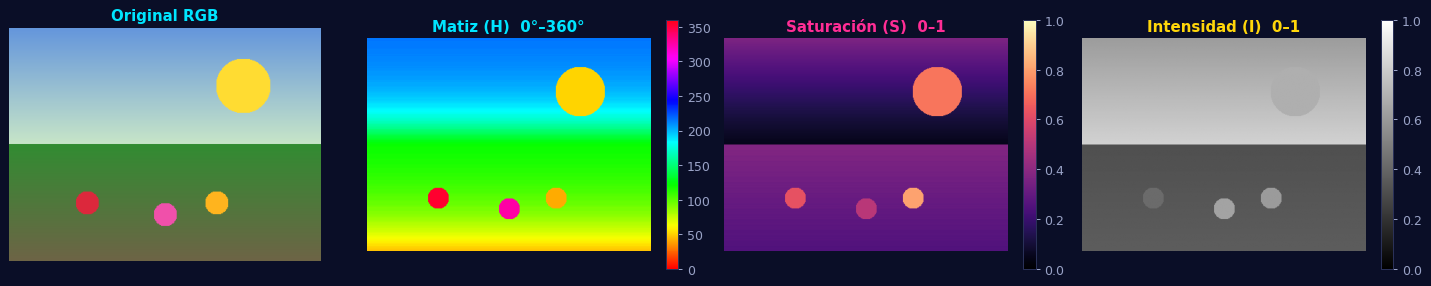

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(img)
axes[0].set_title('Original RGB')
axes[0].axis('off')

# H con colormap circular
im_h = axes[1].imshow(H, cmap='hsv', vmin=0, vmax=360)
axes[1].set_title('Matiz (H)  0°–360°', color=CYAN)
axes[1].axis('off')
plt.colorbar(im_h, ax=axes[1], fraction=0.04)

im_s = axes[2].imshow(S, cmap='magma', vmin=0, vmax=1)
axes[2].set_title('Saturación (S)  0–1', color=MAGENTA)
axes[2].axis('off')
plt.colorbar(im_s, ax=axes[2], fraction=0.04)

im_i = axes[3].imshow(I, cmap='gray', vmin=0, vmax=1)
axes[3].set_title('Intensidad (I)  0–1', color=YELLOW)
axes[3].axis('off')
plt.colorbar(im_i, ax=axes[3], fraction=0.04)

plt.tight_layout()
plt.show()


### 🔍 Observa con cuidado

1. **Matiz** cambia abruptamente porque es un ángulo: zonas de píxeles de color similar comparten el mismo tono.
2. **Saturación** es alta en zonas de colores vivos y baja en zonas blanquecinas/grises.
3. **Intensidad** se parece a una versión en escala de grises de la imagen. De hecho, es el promedio RGB.

### Verificación numérica: ¿mi implementación es correcta?

Vamos a comparar con la de **OpenCV** (si está disponible) que usa HSV (similar pero no idéntico). Como referencia alternativa, también podemos comparar valores en píxeles conocidos.


In [9]:
# --- Verificación con píxeles de prueba ---
casos_prueba = {
    'Rojo puro':    ([255,   0,   0], 0.0,   1.0,   1/3),
    'Verde puro':   ([  0, 255,   0], 120.0, 1.0,   1/3),
    'Azul puro':    ([  0,   0, 255], 240.0, 1.0,   1/3),
    'Amarillo':     ([255, 255,   0], 60.0,  1.0,   2/3),
    'Cian':         ([  0, 255, 255], 180.0, 1.0,   2/3),
    'Magenta':      ([255,   0, 255], 300.0, 1.0,   2/3),
    'Blanco':       ([255, 255, 255], 0.0,   0.0,   1.0),
    'Negro':        ([  0,   0,   0], 0.0,   0.0,   0.0),
    'Gris medio':   ([128, 128, 128], 0.0,   0.0,   128/255),
}

print(f"{'Caso':<12} | {'RGB':<15} | {'H esperado':>10} | {'H calc':>8} | {'S esp':>6} | {'S calc':>7} | {'I esp':>6} | {'I calc':>7}")
print('-' * 100)
for nombre, (rgb, h_exp, s_exp, i_exp) in casos_prueba.items():
    pix = np.array([[rgb]], dtype=np.uint8)
    h_c, s_c, i_c = rgb_to_hsi_manual(pix)
    print(f"{nombre:<12} | {str(rgb):<15} | {h_exp:>10.1f} | {h_c[0,0]:>8.1f} | {s_exp:>6.2f} | {s_c[0,0]:>7.3f} | {i_exp:>6.3f} | {i_c[0,0]:>7.3f}")

print('\n✓ Si los valores calculados coinciden con los esperados, tu implementación es correcta.')


Caso         | RGB             | H esperado |   H calc |  S esp |  S calc |  I esp |  I calc
----------------------------------------------------------------------------------------------------
Rojo puro    | [255, 0, 0]     |        0.0 |      0.0 |   1.00 |   1.000 |  0.333 |   0.333
Verde puro   | [0, 255, 0]     |      120.0 |    120.0 |   1.00 |   1.000 |  0.333 |   0.333
Azul puro    | [0, 0, 255]     |      240.0 |    240.0 |   1.00 |   1.000 |  0.333 |   0.333
Amarillo     | [255, 255, 0]   |       60.0 |     60.0 |   1.00 |   1.000 |  0.667 |   0.667
Cian         | [0, 255, 255]   |      180.0 |    180.0 |   1.00 |   1.000 |  0.667 |   0.667
Magenta      | [255, 0, 255]   |      300.0 |    300.0 |   1.00 |   1.000 |  0.667 |   0.667
Blanco       | [255, 255, 255] |        0.0 |      0.0 |   0.00 |   0.000 |  1.000 |   1.000
Negro        | [0, 0, 0]       |        0.0 |      0.0 |   0.00 |   0.000 |  0.000 |   0.000
Gris medio   | [128, 128, 128] |        0.0 |      0.0 |   0.0

### 🎯 Ejercicio 3.1

Construye una **imagen sintética** de 300×300 píxeles dividida en 3 columnas: la primera es rojo puro, la segunda verde puro, la tercera azul puro. Aplica `rgb_to_hsi_manual` y visualiza H, S, I. ¿El matiz coincide con lo esperado (0°, 120°, 240°)?


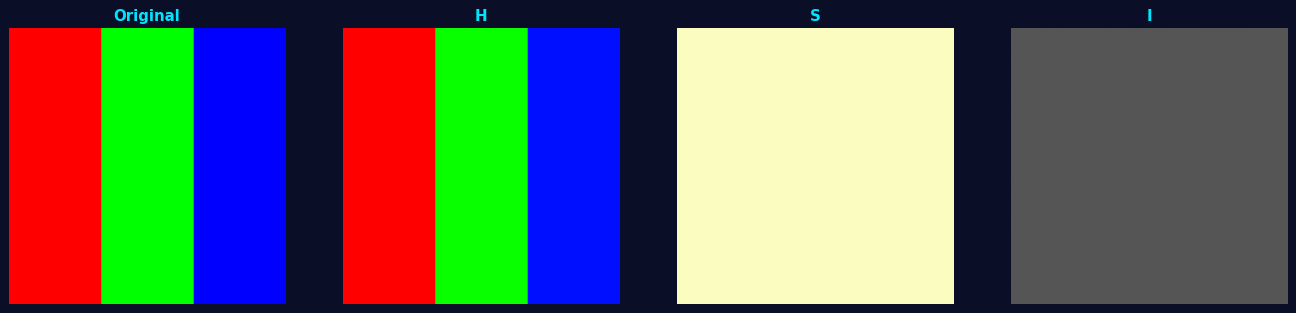

H promedio de cada columna:
  Rojo:  0.0°    (esperado 0°)
  Verde: 120.0°   (esperado 120°)
  Azul:  240.0°   (esperado 240°)


In [10]:
# TU CÓDIGO AQUÍ
test = np.zeros((300, 300, 3), dtype=np.uint8)
test[:, :100]    = [255, 0, 0]    # rojo
test[:, 100:200] = [0, 255, 0]    # verde
test[:, 200:]    = [0, 0, 255]    # azul

H_t, S_t, I_t = rgb_to_hsi_manual(test)

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
axes[0].imshow(test);                               axes[0].set_title('Original');     axes[0].axis('off')
axes[1].imshow(H_t, cmap='hsv', vmin=0, vmax=360);  axes[1].set_title('H');            axes[1].axis('off')
axes[2].imshow(S_t, cmap='magma', vmin=0, vmax=1);  axes[2].set_title('S');            axes[2].axis('off')
axes[3].imshow(I_t, cmap='gray',  vmin=0, vmax=1);  axes[3].set_title('I');            axes[3].axis('off')
plt.tight_layout(); plt.show()

print(f'H promedio de cada columna:')
print(f'  Rojo:  {H_t[:, 50].mean():.1f}°    (esperado 0°)')
print(f'  Verde: {H_t[:, 150].mean():.1f}°   (esperado 120°)')
print(f'  Azul:  {H_t[:, 250].mean():.1f}°   (esperado 240°)')


---
## 🔄 Bloque 4 · HSI → RGB (conversión inversa)

Ahora la vuelta. Como el círculo de H se divide en 3 sectores de 120°, hay **tres casos** según dónde caiga H (G&W, ec. 6.2-5 a 6.2-7).

### Sector RG  (0° ≤ H < 120°)

$$B = I(1 - S)$$
$$R = I\left[1 + \frac{S\cos H}{\cos(60° - H)}\right]$$
$$G = 3I - (R + B)$$

### Sector GB  (120° ≤ H < 240°)

$$H' = H - 120°$$
$$R = I(1 - S)$$
$$G = I\left[1 + \frac{S\cos H'}{\cos(60° - H')}\right]$$
$$B = 3I - (R + G)$$

### Sector BR  (240° ≤ H < 360°)

$$H' = H - 240°$$
$$G = I(1 - S)$$
$$B = I\left[1 + \frac{S\cos H'}{\cos(60° - H')}\right]$$
$$R = 3I - (G + B)$$

Observa el patrón: en cada sector, un canal se "apaga" con `I(1-S)`, otro usa la fórmula del coseno, y el tercero se completa para que `R + G + B = 3I`.


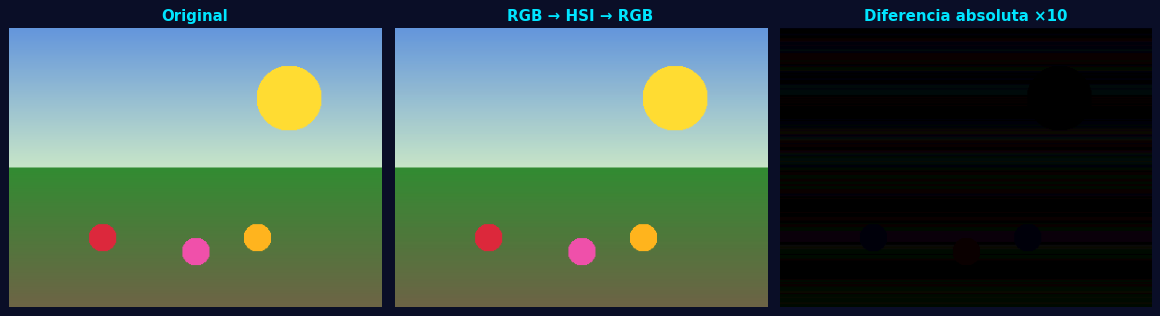

Error máximo:      1   (de 255)
Error promedio:    0.294
% píxeles idénticos: 70.6%

💡 Pequeños errores (<3) son aceptables por cuantización uint8 y precisión de float.


In [11]:
def hsi_to_rgb_manual(H, S, I):
    """Conversión HSI → RGB siguiendo G&W ec. 6.2-5 a 6.2-7.

    Parámetros
    ----------
    H : ndarray, grados [0, 360)
    S : ndarray, [0, 1]
    I : ndarray, [0, 1]

    Retorna
    -------
    rgb_uint8 : ndarray (H, W, 3), dtype=uint8
    """
    H = np.asarray(H, dtype=np.float64)
    S = np.asarray(S, dtype=np.float64)
    I = np.asarray(I, dtype=np.float64)

    # Convertir H a radianes para las fórmulas trigonométricas
    R = np.zeros_like(I)
    G = np.zeros_like(I)
    B = np.zeros_like(I)

    # --- Sector RG: 0° ≤ H < 120° ---
    mask = (H >= 0) & (H < 120)
    if np.any(mask):
        Hm = np.radians(H[mask])
        B[mask] = I[mask] * (1 - S[mask])
        R[mask] = I[mask] * (1 + S[mask] * np.cos(Hm) / np.cos(np.radians(60) - Hm))
        G[mask] = 3 * I[mask] - (R[mask] + B[mask])

    # --- Sector GB: 120° ≤ H < 240° ---
    mask = (H >= 120) & (H < 240)
    if np.any(mask):
        Hm = np.radians(H[mask] - 120)
        R[mask] = I[mask] * (1 - S[mask])
        G[mask] = I[mask] * (1 + S[mask] * np.cos(Hm) / np.cos(np.radians(60) - Hm))
        B[mask] = 3 * I[mask] - (R[mask] + G[mask])

    # --- Sector BR: 240° ≤ H < 360° ---
    mask = (H >= 240) & (H < 360)
    if np.any(mask):
        Hm = np.radians(H[mask] - 240)
        G[mask] = I[mask] * (1 - S[mask])
        B[mask] = I[mask] * (1 + S[mask] * np.cos(Hm) / np.cos(np.radians(60) - Hm))
        R[mask] = 3 * I[mask] - (G[mask] + B[mask])

    # Recortar a [0, 1] para absorber pequeños errores de punto flotante,
    # escalar a [0, 255] y pasar a uint8
    rgb = np.stack([R, G, B], axis=-1)
    rgb = np.clip(rgb, 0, 1)
    return (rgb * 255).astype(np.uint8)

# --- Test: ida y vuelta debe devolver la imagen original ---
H_orig, S_orig, I_orig = rgb_to_hsi_manual(img)
img_reconstruida = hsi_to_rgb_manual(H_orig, S_orig, I_orig)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img);               axes[0].set_title('Original');                  axes[0].axis('off')
axes[1].imshow(img_reconstruida);  axes[1].set_title('RGB → HSI → RGB');           axes[1].axis('off')

diff = np.abs(img.astype(np.int32) - img_reconstruida.astype(np.int32)).astype(np.uint8)
axes[2].imshow(diff * 10, vmin=0, vmax=255)   # ×10 para que se note si hay algo
axes[2].set_title('Diferencia absoluta ×10')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f'Error máximo:      {diff.max()}   (de 255)')
print(f'Error promedio:    {diff.mean():.3f}')
print(f'% píxeles idénticos: {(diff == 0).mean()*100:.1f}%')
print()
print('💡 Pequeños errores (<3) son aceptables por cuantización uint8 y precisión de float.')


---
## 🎨 Bloque 5 · Manipulación creativa en HSI

**Aquí es donde HSI brilla.** Algunos efectos son casi triviales en HSI y **muy difíciles en RGB**.

### Efecto 1: Rotar el matiz (cambiar todos los colores a la vez)

Simplemente sumamos un offset a H (con wrap-around mod 360). Todos los colores rotan, pero **el brillo y la saturación se mantienen**.


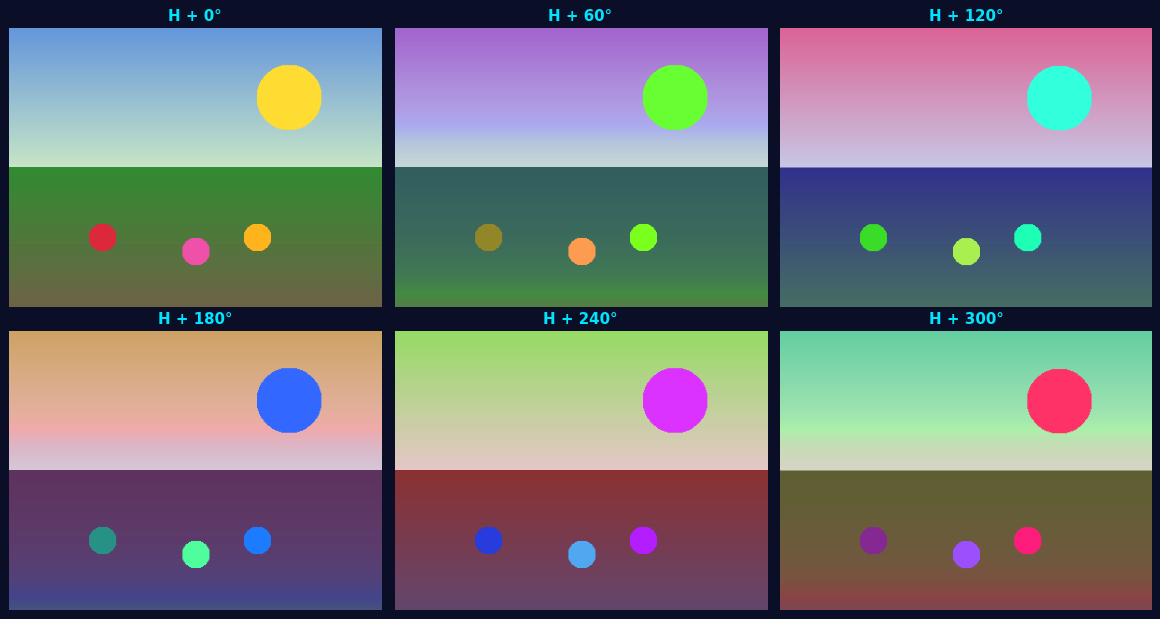

👀 Observa cómo la estructura de la imagen (brillo/contraste) se mantiene,
   pero el "esquema de colores" rota por completo.


In [12]:
def rotar_matiz(imagen, grados):
    """Rota el matiz de toda la imagen por el ángulo dado."""
    H, S, I = rgb_to_hsi_manual(imagen)
    H_nuevo = (H + grados) % 360
    return hsi_to_rgb_manual(H_nuevo, S, I)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, deg in zip(axes.flat, [0, 60, 120, 180, 240, 300]):
    ax.imshow(rotar_matiz(img, deg))
    ax.set_title(f'H + {deg}°')
    ax.axis('off')
plt.tight_layout()
plt.show()

print('👀 Observa cómo la estructura de la imagen (brillo/contraste) se mantiene,')
print('   pero el "esquema de colores" rota por completo.')


### Efecto 2: Aumentar / reducir saturación

Multiplicar S por una constante:
- `× 0` → imagen **desaturada** (en escala de grises, pero con la intensidad original)
- `× 2` → imagen **hiper-saturada** (colores Pop-art)


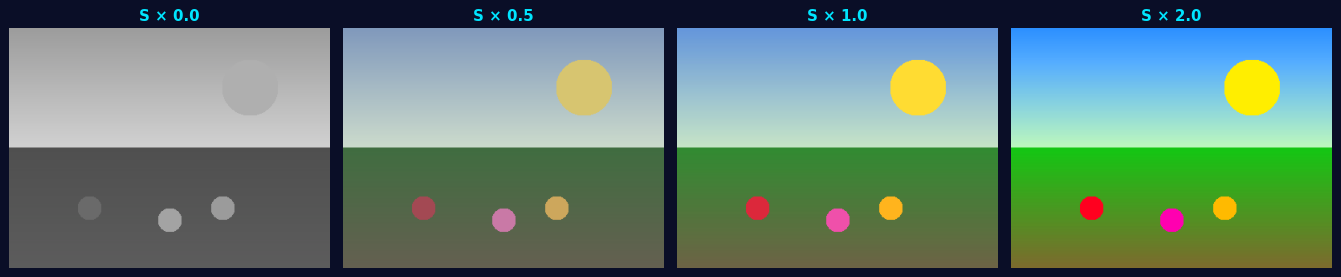

In [13]:
def ajustar_saturacion(imagen, factor):
    """factor < 1 desatura; factor > 1 satura."""
    H, S, I = rgb_to_hsi_manual(imagen)
    S_nuevo = np.clip(S * factor, 0, 1)
    return hsi_to_rgb_manual(H, S_nuevo, I)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, f in zip(axes, [0.0, 0.5, 1.0, 2.0]):
    ax.imshow(ajustar_saturacion(img, f))
    ax.set_title(f'S × {f}')
    ax.axis('off')
plt.tight_layout()
plt.show()


### Efecto 3: Ecualizar solo la intensidad

**Caso clásico del libro.** Si ecualizas el histograma sobre los 3 canales RGB directamente, los colores se degradan porque alteras el matiz. Si lo haces solo sobre **I**, mejoras el contraste **manteniendo los colores intactos**.


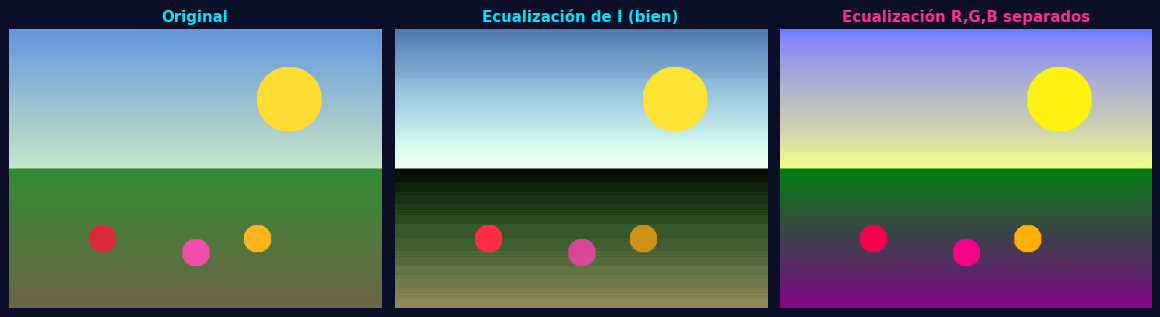

💡 En HSI los colores se conservan; en RGB por canal, los matices se alteran.


In [14]:
def ecualizar_histograma(canal):
    """Ecualización de histograma clásica sobre un canal en [0, 1]."""
    # Cuantizamos a 256 niveles y aplicamos ecualización
    c256 = (canal * 255).astype(np.uint8)
    hist, bins = np.histogram(c256.flatten(), bins=256, range=(0, 256))
    cdf = hist.cumsum()
    cdf_norm = cdf / cdf[-1]
    lut = (cdf_norm * 255).astype(np.uint8)
    eq = lut[c256]
    return eq.astype(np.float64) / 255.0

H, S, I = rgb_to_hsi_manual(img)
I_eq = ecualizar_histograma(I)
img_eq_hsi = hsi_to_rgb_manual(H, S, I_eq)

# Comparación: ecualizar cada canal RGB por separado (mal)
img_eq_rgb = np.zeros_like(img)
for c in range(3):
    img_eq_rgb[:, :, c] = (ecualizar_histograma(img[:, :, c] / 255.0) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(img);          axes[0].set_title('Original');                 axes[0].axis('off')
axes[1].imshow(img_eq_hsi);   axes[1].set_title('Ecualización de I (bien)', color=CYAN);    axes[1].axis('off')
axes[2].imshow(img_eq_rgb);   axes[2].set_title('Ecualización R,G,B separados', color=MAGENTA); axes[2].axis('off')
plt.tight_layout()
plt.show()

print('💡 En HSI los colores se conservan; en RGB por canal, los matices se alteran.')


### Efecto 4: Filtro selectivo por matiz (¡segmentación por color!)

Queremos "pintar de gris todo lo que no sea rojo". En RGB esto es doloroso porque el rojo vive repartido en 3 canales. En HSI es trivial: filtramos por H cerca de 0° (o 360°).


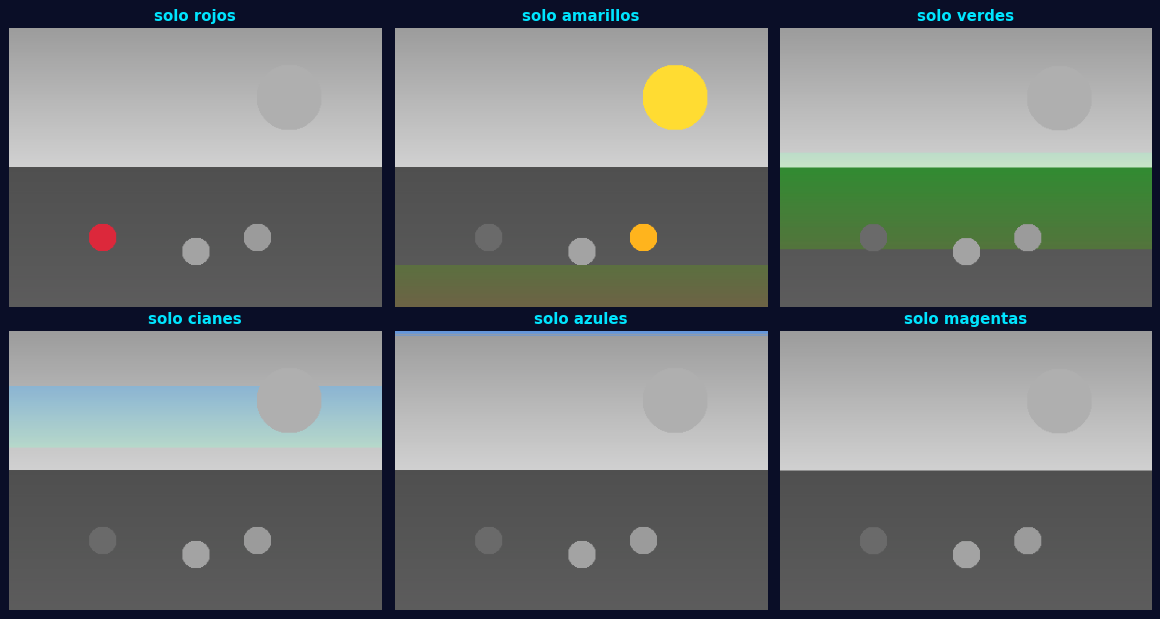

In [15]:
def aislar_matiz(imagen, h_objetivo, tolerancia=20):
    """Mantiene el color solo en píxeles cuyo H esté cerca de h_objetivo (±tolerancia);
    el resto se desatura a gris."""
    H, S, I = rgb_to_hsi_manual(imagen)
    # Distancia angular (ojo con el wrap-around)
    diff = np.abs(H - h_objetivo)
    diff = np.minimum(diff, 360 - diff)
    mascara = diff < tolerancia

    S_nuevo = np.where(mascara, S, 0.0)   # desatura fuera de la máscara
    return hsi_to_rgb_manual(H, S_nuevo, I)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (h, nombre) in zip(axes.flat, [
    (0,   'solo rojos'),
    (60,  'solo amarillos'),
    (120, 'solo verdes'),
    (180, 'solo cianes'),
    (240, 'solo azules'),
    (300, 'solo magentas'),
]):
    ax.imshow(aislar_matiz(img, h, tolerancia=25))
    ax.set_title(nombre)
    ax.axis('off')
plt.tight_layout()
plt.show()


### 🎯 Ejercicio 5.1 · Tu propio efecto

Combina dos o más manipulaciones para crear un efecto nuevo. Algunas ideas:

1. **"Instagram vintage"**: reduce saturación un poco (×0.7) + rota H unos 15° + reduce I en un 10%.
2. **"Atardecer"**: aísla los rojos/amarillos y desatura el resto, pero sube la intensidad de las zonas cálidas.
3. **"Posterizar"**: redondea H a múltiplos de 60° (solo 6 matices posibles).

Elige uno, impleméntalo y compara con el original.


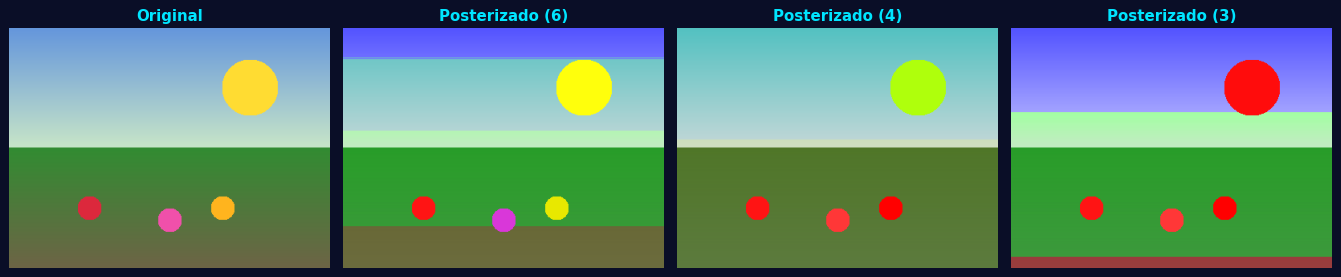

In [16]:
# TU CÓDIGO AQUÍ — ejemplo: posterizar
def posterizar(imagen, n_matices=6):
    """Redondea H a n_matices posibles. Reduce la paleta dramáticamente."""
    H, S, I = rgb_to_hsi_manual(imagen)
    paso = 360 / n_matices
    H_redondeado = np.round(H / paso) * paso
    H_redondeado = H_redondeado % 360
    # Saturar al máximo para look "pop"
    S_nuevo = np.clip(S * 1.3, 0, 1)
    return hsi_to_rgb_manual(H_redondeado, S_nuevo, I)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(img);                     axes[0].set_title('Original');          axes[0].axis('off')
axes[1].imshow(posterizar(img, 6));      axes[1].set_title('Posterizado (6)');   axes[1].axis('off')
axes[2].imshow(posterizar(img, 4));      axes[2].set_title('Posterizado (4)');   axes[2].axis('off')
axes[3].imshow(posterizar(img, 3));      axes[3].set_title('Posterizado (3)');   axes[3].axis('off')
plt.tight_layout(); plt.show()


---
## 🎮 Bloque 6 · Juego libre

**Carga tu propia imagen** y aplica todo lo aprendido. Algunas sugerencias:

1. Una foto tuya o de tus mascotas → aplica rotación de matiz y comparte el resultado con un compañero.
2. Una foto de un paisaje → aísla distintos matices (los verdes del campo, los azules del cielo).
3. Una captura de pantalla → ecualiza solo la I y compara con ecualizar los 3 canales.

### Cómo cargar tu imagen

**Opción A** — Desde tu computadora (si usas Jupyter local):
```python
mi_img = np.array(Image.open('ruta/a/tu/imagen.jpg').convert('RGB'))
```

**Opción B** — Desde una URL:
```python
url = 'https://...'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
with urllib.request.urlopen(req) as r:
    mi_img = np.array(Image.open(BytesIO(r.read())).convert('RGB'))
```

**Opción C** — En Google Colab:
```python
from google.colab import files
uploaded = files.upload()
nombre = list(uploaded.keys())[0]
mi_img = np.array(Image.open(nombre).convert('RGB'))
```


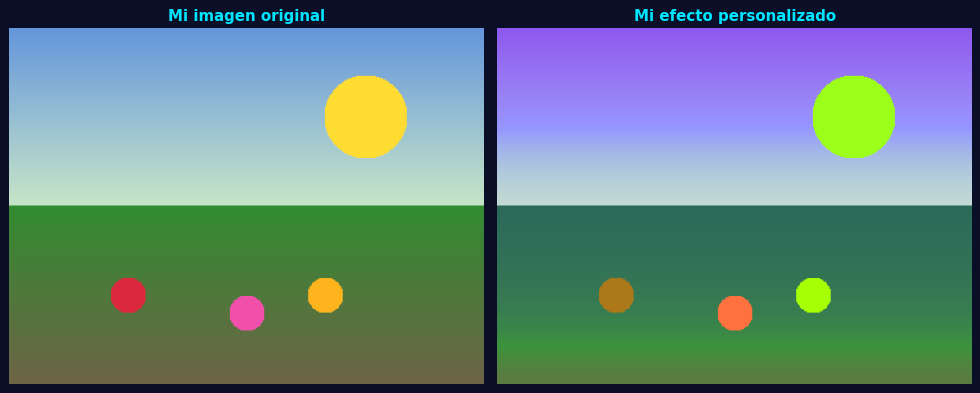

In [17]:
# TU ESPACIO DE JUEGO
# ---------------------------------------
# Carga tu imagen aquí:
mi_img = img  # reemplaza por tu imagen real

# Aplica los efectos que quieras, por ejemplo:
H, S, I = rgb_to_hsi_manual(mi_img)

# --- Experimento 1: tu efecto favorito ---
efecto = hsi_to_rgb_manual((H + 45) % 360, S * 1.2, I)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].imshow(mi_img); axes[0].set_title('Mi imagen original');  axes[0].axis('off')
axes[1].imshow(efecto); axes[1].set_title('Mi efecto personalizado'); axes[1].axis('off')
plt.tight_layout(); plt.show()


In [ ]:
# --- Experimento 2: tu idea aquí ---
# ...


In [ ]:
# --- Experimento 3: tu idea aquí ---
# ...


---
## 📚 Resumen de lo que hicimos

| Bloque | Aprendizaje clave |
|--------|-------------------|
| RGB | Una imagen son 3 matrices superpuestas; cada canal es una imagen en escala de grises |
| CMYK | Invertimos RGB normalizado (ec. 6.2-1) y extraemos K = min(C,M,Y) para ahorrar tinta |
| RGB→HSI | Implementamos las ecuaciones 6.2-2 a 6.2-4 manejando los casos degenerados |
| HSI→RGB | La inversa es por sectores de 120°; hay que respetar los 3 casos |
| Manipulación | HSI permite manipular color (H), viveza (S) e iluminación (I) **por separado** |

## 🔗 Para profundizar

- **González & Woods, Capítulo 6 completo** — conversiones a YIQ, YCbCr, modelos perceptuales avanzados.
- **HSV vs HSI vs HSL** — los 3 son primos pero usan definiciones ligeramente diferentes de "intensidad".
- **CIE L\*a\*b\*** — espacio diseñado para ser perceptualmente uniforme (distancia euclidiana ≈ diferencia visual).
- **OpenCV `cv2.cvtColor`** — implementación industrial rápida con docenas de conversiones.

## ✅ Para la próxima sesión

- Procesamiento **por canal** en el dominio de la frecuencia (Cap. 4)
- Segmentación basada en color (Cap. 10)
- Compresión JPEG (usa YCbCr, ¡no por casualidad!)

---

**Gracias por la clase de hoy 🎨🖥**  
*Si algo no quedó claro o encontraste un bug en el notebook: avísame por Discord / Teams.*
